# 5. State evolution and lifecycle

Two pieces let unitrack maintain *coherent* identities across
time, even when detections are noisy or missing for a few frames:

1. **State** — a pair of pure functions `(Process, Observation)` plus an
   `Initializer`. Each tracklet field has its own state. The
   Process advances the field by `δt`; the Observation fuses
   a measurement when the tracklet matches a detection.
2. **Lifecycle** — `Tentative → Active → Lost → Removed`
   transitions driven by `min_hits` and `max_age`.

This notebook visualizes both on a synthetic clip with
occlusion-style gaps.


In [ ]:
import torch
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import Cosine
from unitrack.data import Detections, FrameContext, TensorSpec, Tracklets
from unitrack.lifecycle import (
    ConfirmedOnly,
    IncludeAll,
    IncludeTentative,
    NoLifecycle,
    StandardLifecycle,
    TrackletStatus,
)
from unitrack.pipeline import Pipe
from unitrack.states import (
    EMADecay,
    EMAFuse,
    FromDetectionField,
    Identity,
    Replace,
    State,
)
from unitrack.states.kalman import KalmanCentroid2D

torch.manual_seed(0)


## State catalogue

The two halves of a State have different signatures:

| | Signature | What it does |
|---|---|---|
| **Process** | `(cs, ctx) → cs'` | advance the field by `δt` |
| **Observation** | `(cs, ds, match, ctx) → cs'` | fuse measurements for matched, apply miss-rule for unmatched |

Built-in catalogue:

- **Identity** (Process): no-op. Pair with `Replace` for fields like kernel embeddings or class labels.
- **Replace** (Observation): matched tracklets adopt the new detection's value verbatim.
- **EMADecay(field, half_life)** (Process): exponential decay toward zero.
- **EMAFuse(field, rho)** (Observation): EMA blend of old/new values for matched.
- **KalmanLinear / KalmanBBox / KalmanCentroid2D / KalmanCentroid3D** (Process): linear-Gaussian predict.
- **KalmanUpdate** (Observation): Joseph-form update.


## Visualizing a Kalman state

A 2D constant-velocity Kalman filter carries a 4D state
`[x, y, vx, vy]` and a 4×4 covariance. The Process advances
`x ← x + vx·δt` (likewise y) and grows the covariance by Q.
The Observation fuses a 2D position measurement.

We'll watch the predicted mean drift forward each frame, then
snap toward the measurement when fused.


In [ ]:
proc = KalmanCentroid2D("centroid", q=0.1, r=0.5)


# Construct a single-tracklet Tracklets snapshot manually.
def _tracklets_one(mean, cov, *, age=1):
    return Tracklets(
        id=torch.tensor([1], dtype=torch.int64),
        status=torch.tensor([int(TrackletStatus.Active)], dtype=torch.int8),
        hits=torch.tensor([5], dtype=torch.int32),
        time_since_update=torch.zeros(1, dtype=torch.int32),
        age=torch.tensor([age], dtype=torch.int32),
        frame_started=torch.zeros(1, dtype=torch.int32),
        frame_last_seen=torch.zeros(1, dtype=torch.int32),
        centroid=mean.unsqueeze(0),
        centroid_cov=cov.unsqueeze(0),
        batch_size=[1],
    )


# Initial state: at origin, moving (3, 1) px/frame, identity covariance.
mean = torch.tensor([0.0, 0.0, 3.0, 1.0])
cov = torch.eye(4) * 0.5
snap = _tracklets_one(mean, cov)

# Step the Process forward 5 frames; record the predicted positions.
ctx = FrameContext.make(frame_idx=0, delta=1.0, fps=1.0)
traj = [snap.centroid[0].clone()]
for k in range(5):
    snap = proc(snap, ctx)
    traj.append(snap.centroid[0].clone())
traj = torch.stack(traj)
print("predicted (x, y, vx, vy) over time:")
print(traj.round(decimals=2))


predicted (x, y, vx, vy) over time:
tensor([[ 0.,  0.,  3.,  1.],
        [ 3.,  1.,  3.,  1.],
        [ 6.,  2.,  3.,  1.],
        [ 9.,  3.,  3.,  1.],
        [12.,  4.,  3.,  1.],
        [15.,  5.,  3.,  1.]])


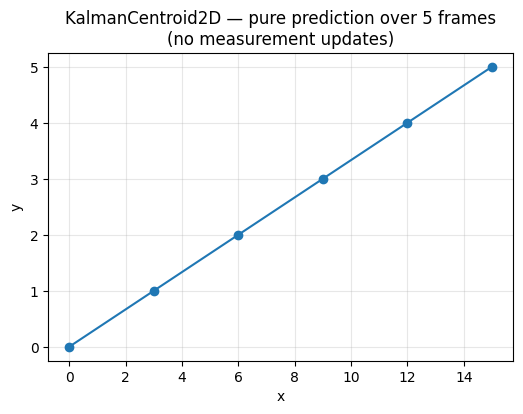

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(traj[:, 0], traj[:, 1], "o-", label="predicted position")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    "KalmanCentroid2D — pure prediction over 5 frames\n(no measurement updates)"
)
ax.grid(alpha=0.3)
plt.show()


Now let's add measurement updates. We'll match the tracklet
against a detection that sits 0.5px off the prediction every
frame. The Joseph-form update tightens the covariance and
nudges the mean toward the measurement.


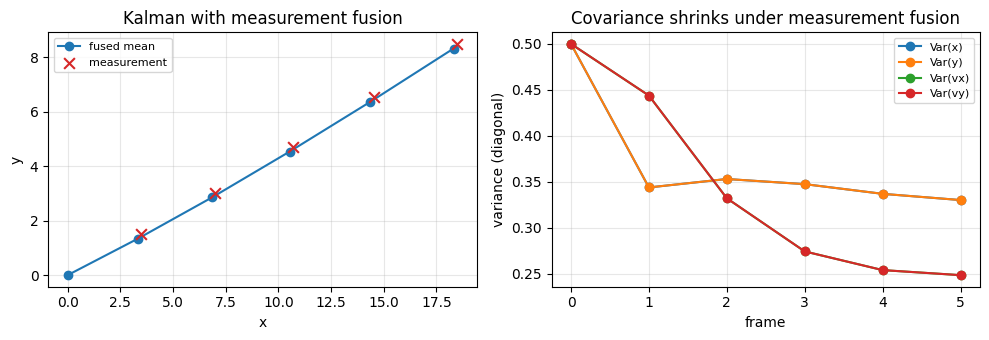

In [ ]:
update = proc.make_update()
snap = _tracklets_one(mean.clone(), cov.clone())

traj = [snap.centroid[0].clone()]
cov_traces = [snap.centroid_cov[0].diagonal().clone()]
meas = []
for k in range(5):
    ctx = FrameContext.make(frame_idx=k + 1, delta=1.0, fps=1.0)
    # 1. Predict
    snap = proc(snap, ctx)
    # 2. Build a fake measurement (offset by 0.5px from prediction).
    true_pos = snap.centroid[0, :2] + torch.tensor([0.5, 0.5])
    meas.append(true_pos.clone())
    ds = Detections(
        index=torch.tensor([0], dtype=torch.int64),
        centroid=true_pos.unsqueeze(0),
        batch_size=[1],
    )
    from unitrack.data import MatchOutcome

    match = MatchOutcome(
        matched_pairs=torch.tensor([[0, 0]], dtype=torch.int64),
        tracklets_residual_index=torch.zeros(0, dtype=torch.int64),
        detections_residual_index=torch.zeros(0, dtype=torch.int64),
        per_match_cost=torch.zeros(1),
        batch_size=[],
    )
    # 3. Fuse measurement
    snap = update(snap, ds, match, ctx)
    traj.append(snap.centroid[0].clone())
    cov_traces.append(snap.centroid_cov[0].diagonal().clone())
traj = torch.stack(traj)
cov_traces = torch.stack(cov_traces)
meas = torch.stack(meas)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(traj[:, 0], traj[:, 1], "o-", label="fused mean")
axes[0].scatter(
    meas[:, 0],
    meas[:, 1],
    marker="x",
    color="tab:red",
    s=60,
    label="measurement",
    zorder=3,
)
axes[0].legend(fontsize=8)
axes[0].set_title("Kalman with measurement fusion")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(alpha=0.3)
for i, lbl in enumerate(["Var(x)", "Var(y)", "Var(vx)", "Var(vy)"]):
    axes[1].plot(cov_traces[:, i].numpy(), label=lbl, marker="o")
axes[1].set_xlabel("frame")
axes[1].set_ylabel("variance (diagonal)")
axes[1].set_title("Covariance shrinks under measurement fusion")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Lifecycle — Tentative → Active → Lost → Removed

`StandardLifecycle(min_hits, max_age, allow_reid)` is unitrack's
default state machine:

- New tracklet enters as **Tentative**.
- Tentative + matched on consecutive frames → **Active** when
  `hits >= min_hits`.
- Tentative + missed → **Removed** (if past grace period).
- Active + missed for `> max_age` frames → **Lost**.
- Lost + missed for another `allow_reid` frames → **Removed**.

We'll trace the lifecycle on a 12-frame clip with one tracklet
that gets occluded for 4 frames (no detections).


In [ ]:
# Build a tracker with a 2-stage min_hits + 3-frame max_age policy.
tracker = unitrack.Tracker(
    root=Pipe(cost=Cosine("kernel"), assoc=Associate(Jonker(threshold=0.5))),
    states={
        "kernel": State(
            schema=TensorSpec(shape=(4,), dtype=torch.float32),
            process=Identity("kernel"),
            observation=Replace("kernel"),
            init=FromDetectionField("kernel"),
        ),
    },
    lifecycle=StandardLifecycle(min_hits=2, max_age=3, allow_reid=2),
    visibility=IncludeAll(),
)
ms = unitrack.MultiStream(tracker)

# 12 frames: present, present, present, present (occluded x4), present, present, present, present.
appearance = torch.tensor([1.0, 0, 0, 0])
present = [True, True, True, True, False, False, False, False, True, True, True, True]

history = []  # list of (status, hits, tsu, age) per frame for tracklet 1
for k, p in enumerate(present):
    if p:
        ds = Detections(
            index=torch.tensor([0], dtype=torch.int64),
            kernel=appearance.unsqueeze(0),
            batch_size=[1],
        )
    else:
        ds = Detections(
            index=torch.zeros(0, dtype=torch.int64),
            kernel=torch.zeros((0, 4), dtype=torch.float32),
            batch_size=[0],
        )
    ctx = FrameContext.make(frame_idx=k, delta=1.0, fps=1.0, stream_key=0)
    res = ms.step(stream_key=0, detections=ds, ctx=ctx)
    # Find tracklet 1 in the snapshot (might be filtered out by Removed).
    snap = res.snapshot
    mask = snap.id == 1
    if mask.any():
        history.append(
            (
                int(snap.status[mask].item()),
                int(snap.hits[mask].item()),
                int(snap.time_since_update[mask].item()),
                int(snap.age[mask].item()),
            )
        )
    else:
        history.append(None)  # was removed
for k, h in enumerate(history):
    print(f"frame {k:2d}  present={int(present[k])}  →  {h}")


frame  0  present=1  →  (0, 1, 0, 1)
frame  1  present=1  →  (1, 2, 0, 2)
frame  2  present=1  →  (1, 3, 0, 3)
frame  3  present=1  →  (1, 4, 0, 4)
frame  4  present=0  →  (1, 4, 1, 5)
frame  5  present=0  →  (1, 4, 2, 6)
frame  6  present=0  →  (1, 4, 3, 7)
frame  7  present=0  →  (2, 4, 4, 8)
frame  8  present=1  →  (1, 5, 0, 9)
frame  9  present=1  →  (1, 6, 0, 10)
frame 10  present=1  →  (1, 7, 0, 11)
frame 11  present=1  →  (1, 8, 0, 12)


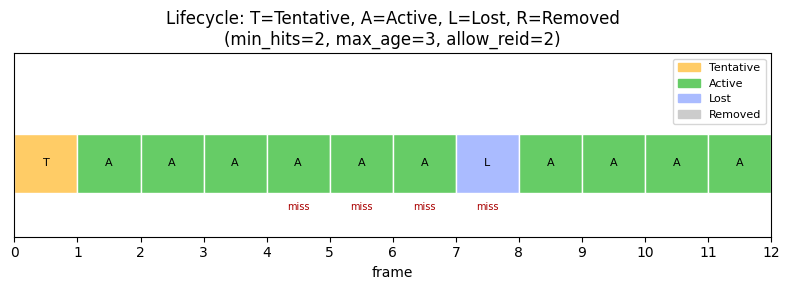

In [ ]:
status_names = ["Tentative", "Active", "Lost", "Removed"]
statuses = [(h[0] if h is not None else 3) for h in history]

fig, ax = plt.subplots(figsize=(8, 3))
for k, (s, p) in enumerate(zip(statuses, present)):
    color = ["#ffcc66", "#66cc66", "#aabbff", "#cccccc"][s]
    ax.barh(0, 1, left=k, color=color, edgecolor="white")
    ax.text(
        k + 0.5,
        0,
        status_names[s][0],
        ha="center",
        va="center",
        fontsize=8,
        color="black",
    )
    if not p:
        ax.text(
            k + 0.5, -0.6, "miss", ha="center", va="center", fontsize=7, color="#aa0000"
        )
ax.set_yticks([])
ax.set_xticks(range(len(history) + 1))
ax.set_xlim(0, len(history))
ax.set_ylim(-1.0, 1.5)
ax.set_xlabel("frame")
ax.set_title(
    "Lifecycle: T=Tentative, A=Active, L=Lost, R=Removed\n(min_hits=2, max_age=3, allow_reid=2)"
)

from matplotlib.patches import Patch

legend = [
    Patch(color="#ffcc66", label="Tentative"),
    Patch(color="#66cc66", label="Active"),
    Patch(color="#aabbff", label="Lost"),
    Patch(color="#cccccc", label="Removed"),
]
ax.legend(handles=legend, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


Reading the timeline:

- Frames 0–1: Tentative. The tracklet is being established.
- Frame 2 onwards: Active (`hits >= 2`).
- Frames 4–7: detection misses. `time_since_update` grows.
  When it exceeds `max_age=3` the tracklet transitions to Lost.
- Frames 8 onwards: detection re-appears, the Lost tracklet
  re-acquires the same identity and goes back to Active.

## Visibility — what does the caller see?

Three policies decide which IDs are visible to the caller of
`Tracker.step`:

- `ConfirmedOnly`: only Active tracklets that matched this frame.
- `IncludeTentative`: also expose Tentative IDs.
- `IncludeAll`: every live tracklet.

Most production trackers use `ConfirmedOnly` to suppress
flicker from unconfirmed detections.


## What's next

Notebook **6** assembles everything you've seen — costs,
gates, combinators, states, lifecycle — into a K=2 cascaded
canonical configuration, runs it on a synthetic
clip with known ground truth, and visualizes the resulting
ID assignments.
